In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Encoder Network
# ----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# ----------------------------
# Decoder Network (Learned Variance)
# ----------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv_base = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),  # 14x14 -> 28x28
            nn.ReLU()
        )

        # Two output heads:
        self.out_mu = nn.Conv2d(32, 1, kernel_size=3, padding=1)       # Mean image
        self.out_logvar = nn.Conv2d(32, 1, kernel_size=3, padding=1)   # Log-variance

    def forward(self, z):
        x = self.fc(z).view(-1, 64, 7, 7)
        x = self.deconv_base(x)
        mu = torch.sigmoid(self.out_mu(x))  # constrain to [0,1] pixel space
        logvar = self.out_logvar(x)         # unconstrained
        logvar = torch.clamp(logvar, min=-6.0, max=3.0)  # Clamp safely here
        return mu, logvar

# ----------------------------
# VAE Wrapper
# ----------------------------
class (nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu_z, logvar_z = self.encoder(x)                 # encoder outputs
        z = self.reparameterize(mu_z, logvar_z)          # latent sample
        mu_x, logvar_x = self.decoder(z)                 # decoder outputs
        return mu_x, logvar_x, mu_z, logvar_z, z         # outputs needed for ELBO

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def get_mnist_dataloaders(batch_size=128):
    transform = transforms.Compose([transforms.ToTensor()])
    full_train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)
    train_set, val_set = random_split(full_train_set, [50000, 10000])
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True),
        DataLoader(val_set, batch_size=batch_size, shuffle=False),
        DataLoader(test_set, batch_size=batch_size, shuffle=False)
    )

def elbo_loss(x, mu_x, logvar_x, mu_z, logvar_z):
    B = x.size(0)
    x = x.view(B, -1)
    mu_x = mu_x.view(B, -1)
    logvar_x = logvar_x.view(B, -1)

    eps = 1e-6
    var = torch.exp(logvar_x) + eps  # Safe variance

    # Numerically stable Gaussian log-likelihood
    recon_loss = 0.5 * (
        torch.log(2 * torch.pi * var) + ((x - mu_x) ** 2) / var
    )
    recon_loss = torch.sum(recon_loss, dim=1)

    # KL divergence
    kl_div = -0.5 * torch.sum(1 + logvar_z - mu_z.pow(2) - logvar_z.exp(), dim=1)

    return torch.mean(recon_loss + kl_div)

In [3]:
import torch
import matplotlib.pyplot as plt

def train_vae(model, train_loader, val_loader, optimizer,
                                   num_epochs=100, patience=10, device='cuda'):

    model = model.to(device)
    train_elbo, val_elbo = [], []

    best_val_elbo = float('-inf')
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train_loss = 0
        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()
            mu_x, logvar_x, mu_z, logvar_z, _ = model(x_batch)
            loss = elbo_loss(x_batch, mu_x, logvar_x, mu_z, logvar_z)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_elbo.append(-avg_train_loss)

        # --- Validation ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x_val, _ in val_loader:
                x_val = x_val.to(device)
                mu_x, logvar_x, mu_z, logvar_z, _ = model(x_val)
                loss = elbo_loss(x_val, mu_x, logvar_x, mu_z, logvar_z)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_elbo.append(-avg_val_loss)

        print(f"Epoch {epoch:02d} | Train ELBO: {-avg_train_loss:.4f} | Val ELBO: {-avg_val_loss:.4f}")

        # Early stopping logic
        if -avg_val_loss > best_val_elbo:
            best_val_elbo = -avg_val_loss
            epochs_without_improvement = 0
            best_model_state = model.state_dict()
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Stopping early at epoch {epoch} due to no improvement in validation ELBO.")
            break

    # Restore best model
    model.load_state_dict(best_model_state)

    # Plot ELBO
    plt.plot(train_elbo, label='Train ELBO')
    plt.plot(val_elbo, label='Validation ELBO')
    plt.xlabel('Epoch')
    plt.ylabel('ELBO')
    plt.legend()
    plt.title('ELBO vs Epoch')
    plt.show()

    return train_elbo, val_elbo



In [4]:
import torchvision.utils as vutils

def test_vae_reconstruction_and_generation(model, test_loader, device='cuda'):
    model.eval()
    model = model.to(device)

    # Get a single batch from test set
    x_test, _ = next(iter(test_loader))
    x_test = x_test[:32].to(device)  # use only first 32 for display
    with torch.no_grad():
        mu_z, logvar_z = model.encoder(x_test)
        z = model.reparameterize(mu_z, logvar_z)
        mu_x, logvar_x = model.decoder(z)
        std_x = torch.exp(0.5 * logvar_x)
        recon_x = mu_x + std_x * torch.randn_like(std_x)  # sample x' ~ N(mu, sigma²)

    # Arrange originals and reconstructions side-by-side
    grid = torch.cat([x_test.cpu(), recon_x.cpu()], dim=0)
    grid_img = vutils.make_grid(grid, nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Top: Original | Bottom: Reconstruction')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

def generate_from_prior(model, num_samples=64, device='cuda'):
    model.eval()
    model = model.to(device)

    with torch.no_grad():
        z = torch.randn(num_samples, model.encoder.fc_mu.out_features).to(device)
        mu_x, logvar_x = model.decoder(z)
        std_x = torch.exp(0.5 * logvar_x)
        gen_x = mu_x + std_x * torch.randn_like(std_x)

    grid_img = vutils.make_grid(gen_x.cpu(), nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Generated Samples from Prior')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()


Epoch 01 | Train ELBO: 250.9339 | Val ELBO: 819.1601
Epoch 02 | Train ELBO: 926.7813 | Val ELBO: 1014.3523
Epoch 03 | Train ELBO: 1067.5350 | Val ELBO: 1105.3409
Epoch 04 | Train ELBO: 1128.1027 | Val ELBO: 1147.0327
Epoch 05 | Train ELBO: 1160.1638 | Val ELBO: 1171.0308
Epoch 06 | Train ELBO: 1181.7646 | Val ELBO: 1190.6095
Epoch 07 | Train ELBO: 1198.8290 | Val ELBO: 1205.8682
Epoch 08 | Train ELBO: 1212.8018 | Val ELBO: 1217.1564
Epoch 09 | Train ELBO: 1223.8994 | Val ELBO: 1228.0136
Epoch 10 | Train ELBO: 1233.0858 | Val ELBO: 1234.8749
Epoch 11 | Train ELBO: 1240.5267 | Val ELBO: 1242.4655
Epoch 12 | Train ELBO: 1246.9117 | Val ELBO: 1247.7172
Epoch 13 | Train ELBO: 1252.5609 | Val ELBO: 1252.9236
Epoch 14 | Train ELBO: 1257.1846 | Val ELBO: 1257.0371
Epoch 15 | Train ELBO: 1261.5969 | Val ELBO: 1260.5669
Epoch 16 | Train ELBO: 1265.5013 | Val ELBO: 1260.4013
Epoch 17 | Train ELBO: 1268.6422 | Val ELBO: 1266.5195
Epoch 18 | Train ELBO: 1272.0026 | Val ELBO: 1269.9246
Epoch 19 | Tr

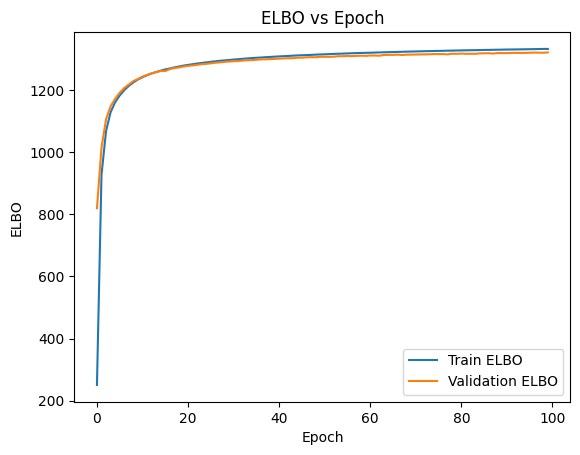

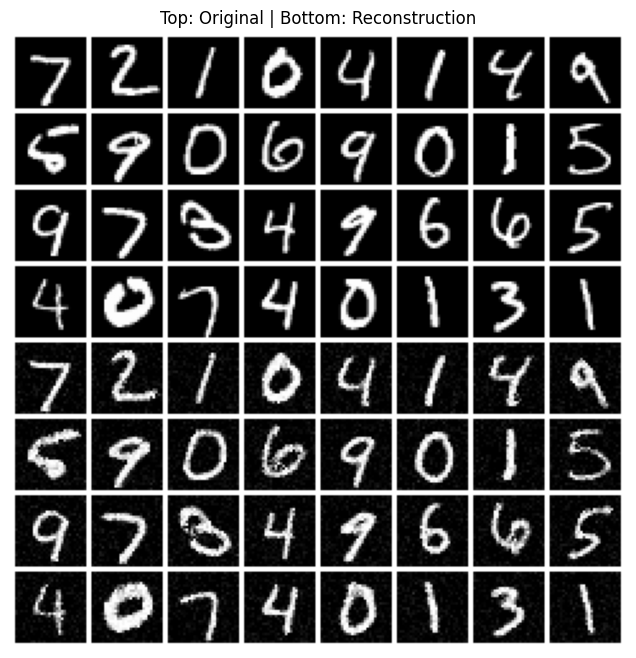

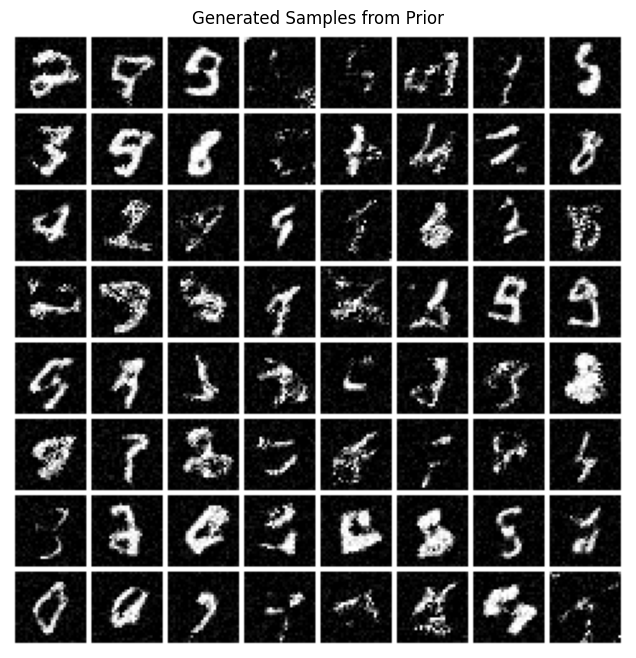

In [45]:
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dim = 20
batch_size = 128

train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_vae(model, train_loader, val_loader, optimizer, num_epochs=100, patience=10, device=device)
test_vae_reconstruction_and_generation(model, test_loader, device=device)
generate_from_prior(model, num_samples=64, device=device)

TASK 3

Epoch 01 | Train ELBO: 161.5434 | Val ELBO: 566.8248
Epoch 02 | Train ELBO: 672.1392 | Val ELBO: 726.2641
Epoch 03 | Train ELBO: 747.1919 | Val ELBO: 771.6538
Epoch 04 | Train ELBO: 782.5407 | Val ELBO: 797.8135
Epoch 05 | Train ELBO: 803.3233 | Val ELBO: 814.1080
Epoch 06 | Train ELBO: 815.2496 | Val ELBO: 822.3750
Epoch 07 | Train ELBO: 823.9487 | Val ELBO: 829.2314
Epoch 08 | Train ELBO: 830.1600 | Val ELBO: 835.2248
Epoch 09 | Train ELBO: 834.9873 | Val ELBO: 839.5018
Epoch 10 | Train ELBO: 839.6220 | Val ELBO: 842.6418
Epoch 11 | Train ELBO: 843.1715 | Val ELBO: 845.7942
Epoch 12 | Train ELBO: 846.4606 | Val ELBO: 849.1911
Epoch 13 | Train ELBO: 849.1664 | Val ELBO: 851.3813
Epoch 14 | Train ELBO: 851.6828 | Val ELBO: 854.1036
Epoch 15 | Train ELBO: 854.1144 | Val ELBO: 855.3924
Epoch 16 | Train ELBO: 856.1001 | Val ELBO: 856.6632
Epoch 17 | Train ELBO: 857.6350 | Val ELBO: 859.2898
Epoch 18 | Train ELBO: 859.7062 | Val ELBO: 859.5385
Epoch 19 | Train ELBO: 861.1113 | Val ELBO: 86

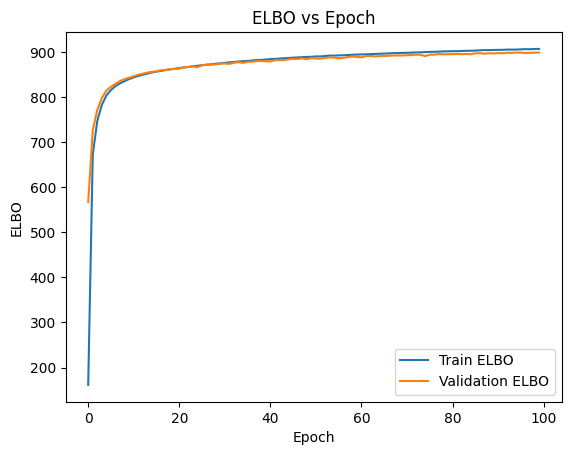

In [6]:
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dim = 2
batch_size = 128

train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_elbo, val_elbo = train_vae(model, train_loader, val_loader, optimizer, device='cuda')

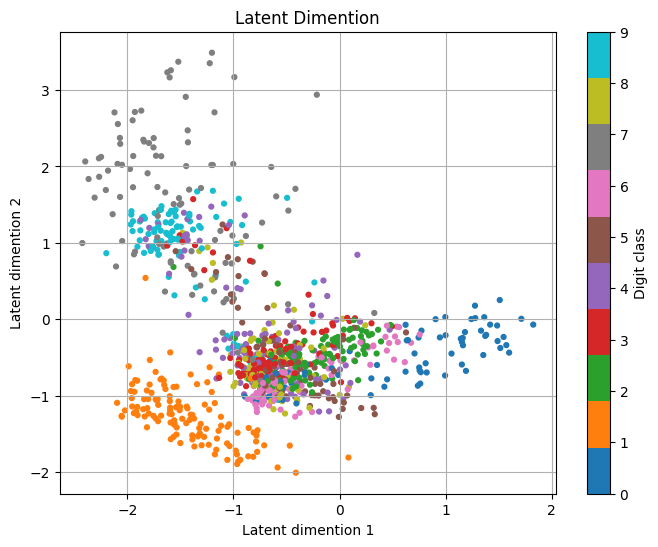

In [33]:
#model.load_state_dict(torch.load("vae_latent_2d.pth"))
import numpy as np

def get_latents(model, test_loader, device, threshold = 1000):
    latent_var = []
    labels = []
    count = 0

    model = model.to(device)
    model.eval()
    
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        mu_z, _ = model.encoder(x_batch)
        latent_var.append(mu_z.detach().cpu().numpy())
        labels.append(y_batch.cpu().numpy())
        count += int(x_batch.size(0))
        if threshold <= count:
            break

    latents = np.vstack(latent_var)[:threshold]
    labels = np.hstack(labels)[:threshold]
    return latents, labels
    

def visualize(latents, labels, title_name, x_name, y_name):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(latents[:, 0], latents[:, 1], c = labels, cmap = 'tab10', s = 12)
    plt.colorbar(scatter, ticks=range(10), label='Digit class')
    plt.title(title_name)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.grid(True)
    plt.show()

latents,labels = get_latents(model, test_loader, device='cuda', threshold=1000)
visualize(latents, labels, "Latent Dimention", "Latent dimention 1", "Latent dimention 2")

Epoch 01 | Train ELBO: 233.6410 | Val ELBO: 725.4576
Epoch 02 | Train ELBO: 867.4250 | Val ELBO: 944.5157
Epoch 03 | Train ELBO: 993.1356 | Val ELBO: 1027.0977
Epoch 04 | Train ELBO: 1049.9199 | Val ELBO: 1062.1453
Epoch 05 | Train ELBO: 1077.1610 | Val ELBO: 1082.6948
Epoch 06 | Train ELBO: 1095.1017 | Val ELBO: 1098.7851
Epoch 07 | Train ELBO: 1108.4319 | Val ELBO: 1109.5143
Epoch 08 | Train ELBO: 1118.9404 | Val ELBO: 1119.4779
Epoch 09 | Train ELBO: 1127.8195 | Val ELBO: 1126.2588
Epoch 10 | Train ELBO: 1135.2558 | Val ELBO: 1133.3675
Epoch 11 | Train ELBO: 1141.8630 | Val ELBO: 1140.0574
Epoch 12 | Train ELBO: 1147.6433 | Val ELBO: 1144.5382
Epoch 13 | Train ELBO: 1152.6711 | Val ELBO: 1148.8693
Epoch 14 | Train ELBO: 1157.6262 | Val ELBO: 1153.7697
Epoch 15 | Train ELBO: 1161.7994 | Val ELBO: 1156.8194
Epoch 16 | Train ELBO: 1165.4289 | Val ELBO: 1160.3405
Epoch 17 | Train ELBO: 1168.9646 | Val ELBO: 1163.3826
Epoch 18 | Train ELBO: 1172.0017 | Val ELBO: 1166.1800
Epoch 19 | Trai

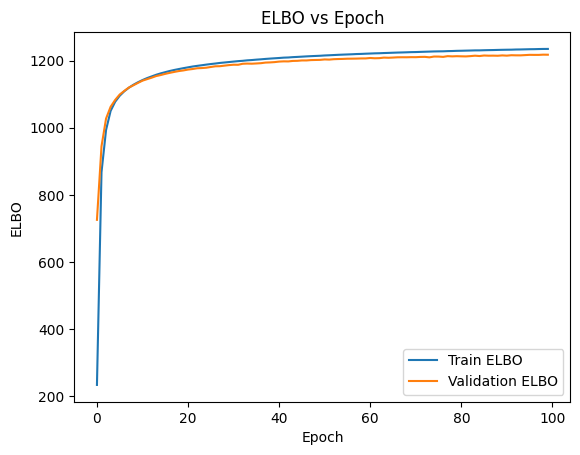

In [31]:
from sklearn.decomposition import PCA
latent_dim = 10
train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model_10 = VAE(latent_dim)
optimizer = torch.optim.Adam(model_10.parameters(), lr=1e-4)

train_elbo, val_elbo = train_vae(model_10, train_loader, val_loader, optimizer, device='cuda')

Shape of matrix U: (1000, 10)


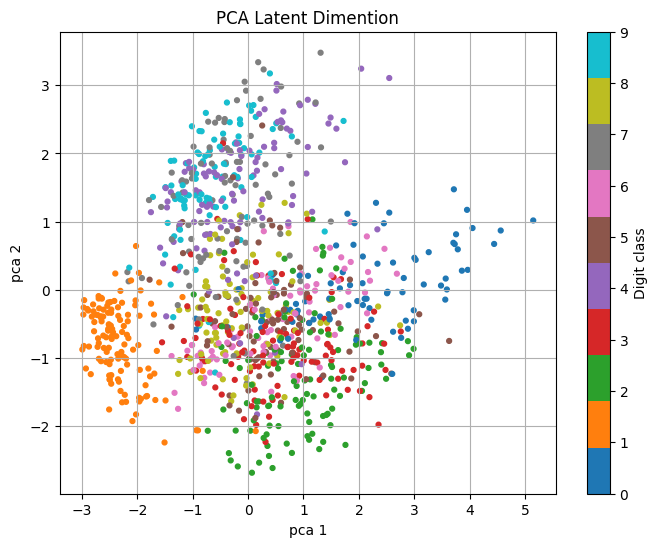

In [44]:
U, labels = get_latents(model_10, test_loader, device=device, threshold=1000)
print(f"Shape of matrix U: {U.shape}")

## PCA analysis on matrix U
pca = PCA(n_components=2)
U_pca = pca.fit_transform(U)

visualize(U_pca, labels, "PCA Latent Dimention", "pca 1", "pca 2")

Task 3c

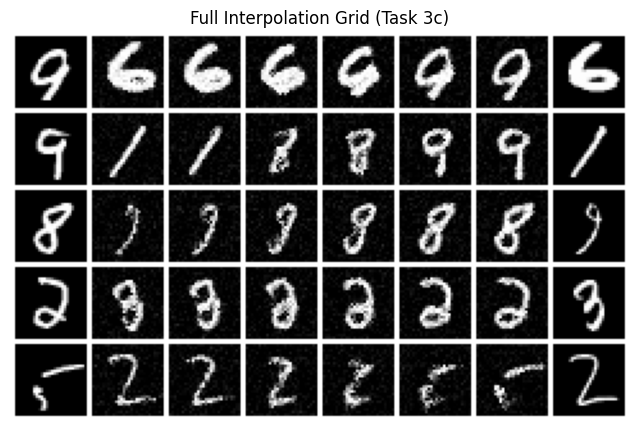

In [56]:
import random 
import torchvision.utils as vutils

def compute_interpolation(model, test_loader, num_rows=5, num_steps=6, device='cuda'):
    lamdas = np.linspace(0, 1, num_steps)
    dataset = test_loader.dataset
    all_rows = []

    for _ in range(num_rows):
        while True:
            idx1 = random.randint(0, len(dataset)-1)
            idx2 = random.randint(0, len(dataset)-1)
            x1, y1 = dataset[idx1]
            x2, y2 = dataset[idx2]
            if y1 != y2:
                break

        z1 = random_latent_sample(model, x1, device=device)
        z2 = random_latent_sample(model, x2, device=device)

        row_images = []
        row_images.append(x1)  # add starting image

        for lamda in lamdas:
            linear_interpolation = lamda * z1 + (1 - lamda) * z2
            decode_z = decode_latent(model, linear_interpolation, device=device)
            row_images.append(decode_z)

        row_images.append(x2)  # add target image

        row_tensor = torch.stack([
            img if isinstance(img, torch.Tensor) else img.data for img in row_images
        ])
        all_rows.append(row_tensor)

    # Combine all rows into grid
    grid = torch.cat(all_rows, dim=0)
    grid_img = vutils.make_grid(grid, nrow=num_steps+2, pad_value=1)

    plt.figure(figsize=(num_steps+2, num_rows * 2))
    plt.axis('off')
    plt.title("Full Interpolation Grid (Task 3c)")
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

compute_interpolation(model, test_loader,num_rows=5, num_steps=6, device=device)    

    
    
        